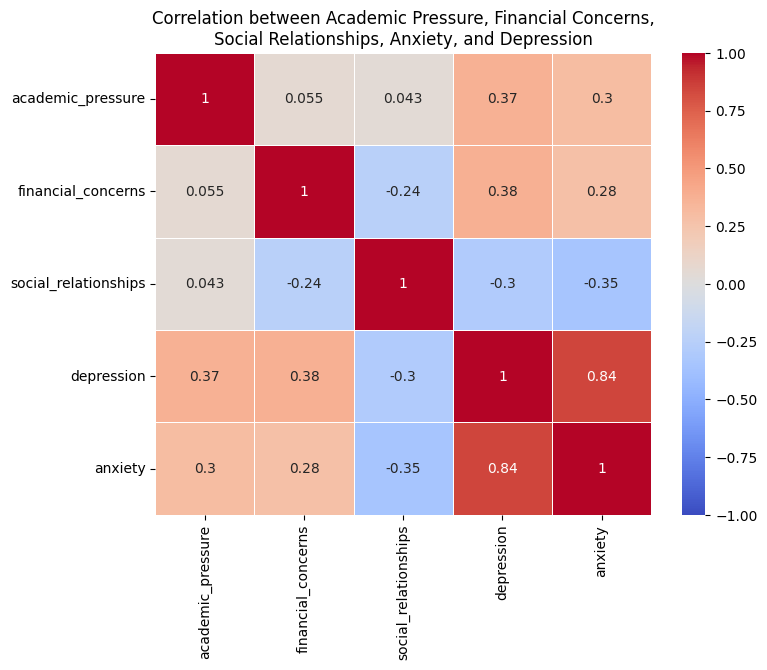

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = 'MentalHealthSurvey.csv'
data = pd.read_csv(file_path)

# Select relevant columns
columns_of_interest = [
    'academic_pressure',
    'financial_concerns',
    'social_relationships',
    'depression',
    'anxiety'
]
data_selected = data[columns_of_interest]

# Calculate correlation matrix
corr_matrix = data_selected.corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation between Academic Pressure, Financial Concerns,\nSocial Relationships, Anxiety, and Depression')
plt.show()

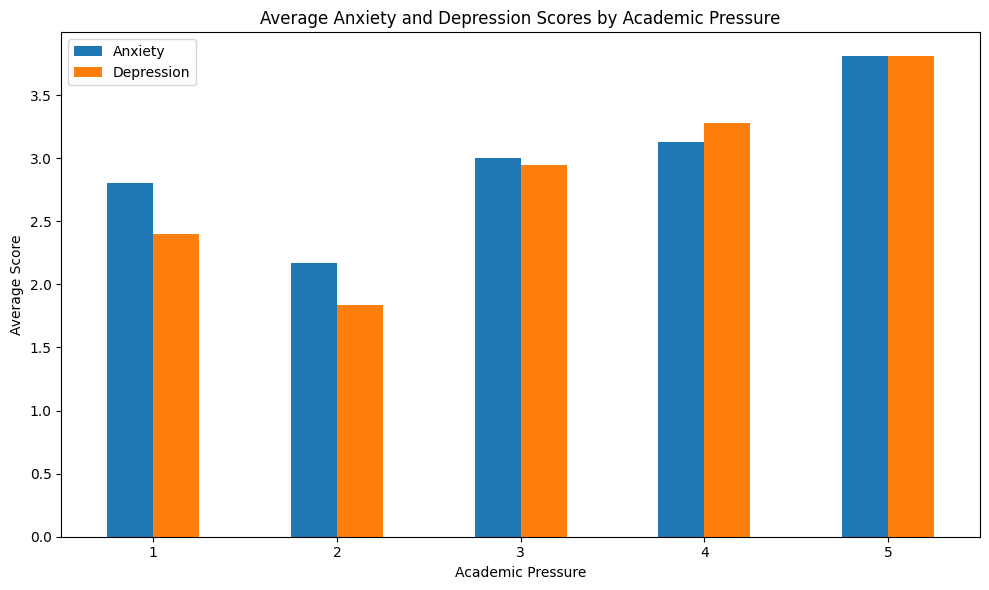

In [5]:
data_academic = data[['academic_pressure', 'anxiety', 'depression']]

# Calculate mean anxiety and depression for each level of academic pressure
mean_scores = data_academic.groupby('academic_pressure')[['anxiety', 'depression']].mean().reset_index()

# Create a bar graph
mean_scores.plot(x='academic_pressure', kind='bar', figsize=(10, 6))
plt.title('Average Anxiety and Depression Scores by Academic Pressure')
plt.xlabel('Academic Pressure')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(['Anxiety', 'Depression'])
plt.tight_layout()
plt.show()

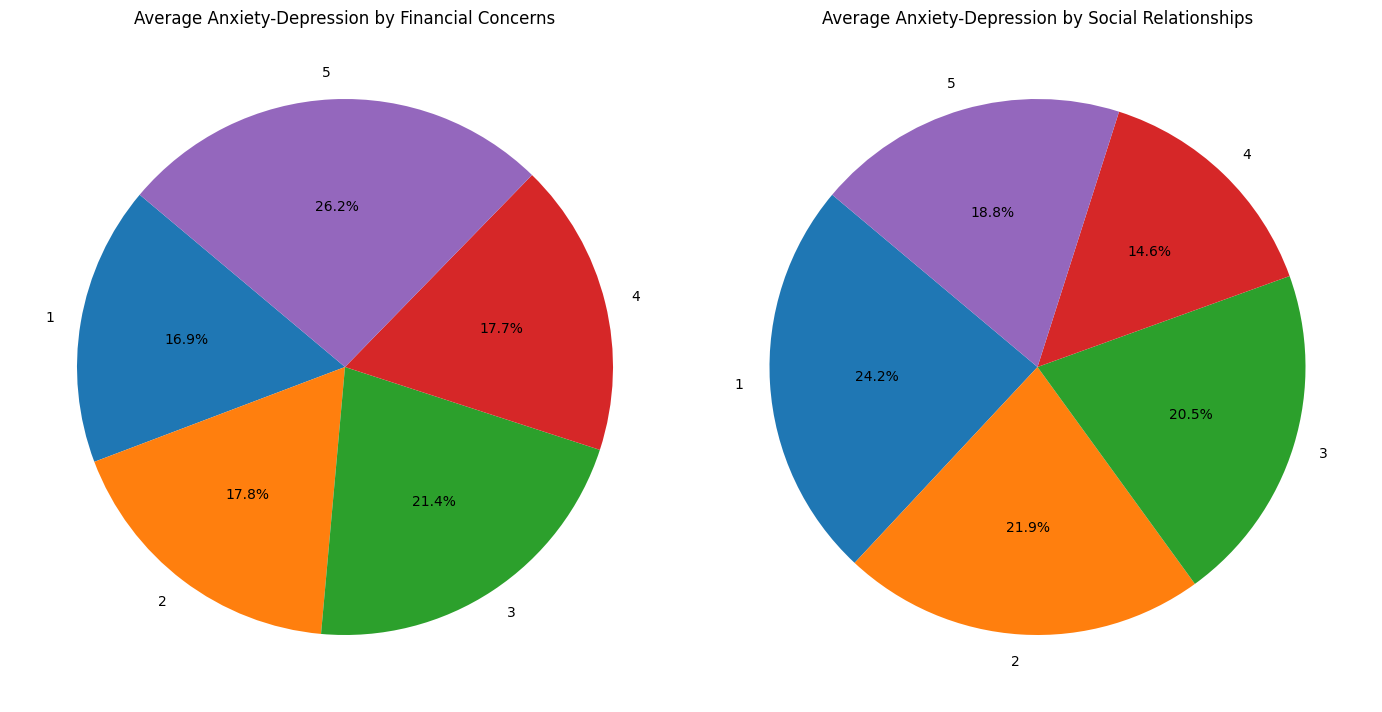

In [6]:
data['avg_mental_health'] = data[['anxiety', 'depression']].mean(axis=1)

# Define thresholds for categorizing mental health
conditions = [
    (data['avg_mental_health'] <= 2),
    (data['avg_mental_health'] > 2) & (data['avg_mental_health'] <= 3),
    (data['avg_mental_health'] > 3)
]
categories = ['Low', 'Moderate', 'High']
data['mental_health_category'] = pd.cut(data['avg_mental_health'], bins=[0, 2, 3, 5], labels=categories, include_lowest=True)

# Pie chart for financial concerns
financial_pie = data.groupby('financial_concerns')['avg_mental_health'].mean()

# Pie chart for social relationships
social_pie = data.groupby('social_relationships')['avg_mental_health'].mean()

# Plotting pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Financial Concerns Pie Chart
financial_pie.plot(kind='pie', autopct='%1.1f%%', startangle=140, ax=axes[0])
axes[0].set_title('Average Anxiety-Depression by Financial Concerns')
axes[0].set_ylabel('')

# Social Relationships Pie Chart
social_pie.plot(kind='pie', autopct='%1.1f%%', startangle=140, ax=axes[1])
axes[1].set_title('Average Anxiety-Depression by Social Relationships')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()